# The small-cap fund that keeps only the *profitable* names — does it win? 🌱
### Profitable small caps (CALF, XSHQ) vs plain small caps (IWM, IJR) vs the S&P 500, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cleaned size premium, tradable?: Busted](https://img.shields.io/badge/Cleaned_size_premium%2C_tradable%3F-Busted-8b949e?style=flat-square)

There's a famous fix for a famous disappointment. The **size premium** — the old idea that small companies out-earn big ones — mostly stopped working. In 2018 a landmark AQR paper ("Size Matters, **If You Control Your Junk**") argued why: small caps are, on average, *junkier* — less profitable, more fragile — and the junk drags the premium to zero. Strip out the junk, keep only the **profitable** small caps, and (they showed) the size premium roars back.

You can *buy* that idea today: ETFs like **CALF** (small caps with the fattest free cash flow) and **XSHQ** (small caps screened for quality) hold only the profitable ones. So here's the clean question — **did they actually beat plain small caps?**

> 📓 **Plain-language layer.** Want the Sharpe ratios, HAC *t*-stats and regressions? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from profitable_small import data, strategy as st

XLEGS = {"CALF": "x_CALF", "XSHQ": "x_XSHQ", "IWM": "x_IWM", "IJR": "x_IJR", "SPY": "x_SPY"}
RLEGS = {"CALF": "r_CALF", "XSHQ": "r_XSHQ", "IWM": "r_IWM", "IJR": "r_IJR", "SPY": "r_SPY"}
COLOR = {"CALF": GREEN, "XSHQ": "#2f9e6f", "IWM": GREY, "IJR": "#6f7a86", "SPY": RED}

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    FRAME = data.daily_frame(PRICES, asof=data.AS_OF)
else:
    PRICES = FRAME = None
print("real tape cached:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '3ec88092fc34', 'window': '2017-06-20 -> 2026-06-30', 'n_race': 2269, 'race': {'CALF': {'exc': 10.2, 'vol': 25.97, 'sr': 0.393, 'dd': -49.2, 'kind': 'profitable small'}, 'XSHQ': {'exc': 8.99, 'vol': 22.86, 'sr': 0.393, 'dd': -40.2, 'kind': 'profitable small'}, 'IWM': {'exc': 10.11, 'vol': 23.78, 'sr': 0.425, 'dd': -43.0, 'kind': 'plain small'}, 'IJR': {'exc': 10.21, 'vol': 23.6, 'sr': 0.433, 'dd': -46.1, 'kind': 'plain small (earnings screen)'}, 'SPY': {'exc': 13.31, 'vol': 18.68, 'sr': 0.712, 'dd': -33.9, 'kind': 'large cap'}}, 'boot': {'CALF': (0.393, -0.234, 0.997, 0.108), 'XSHQ': (0.393, -0.209, 0.994, 0.094), 'IWM': (0.425, -0.209, 1.081, 0.099), 'IJR': (0.433, -0.204, 1.073, 0.089), 'SPY': (0.712, 0.109, 1.406, 0.012)}, 'pairs': {'CALF vs IWM': (0.393, 0.425, -0.033, -0.323, 0.238, 0.584, 0.033, 0.02), 'CALF vs IJR': (0.393, 0.433, -0.04, -0.274, 0.17, 0.643, -0.004, -0.0), 'CALF vs SPY': (0.393, 0.712, -0.32, -0.76, 0.063, 0.946, -1.235, -0.6), 'XSHQ vs IWM': (0.396, 0.434, -0.039, -0.286, 0.193, 0.627, -0.509, -0.43), 'XSHQ vs IJR': (0.396, 0.438, -0.043, -0.252, 0.135, 0.671, -0.516, -0.54), 'XSHQ vs SPY': (0.396, 0.73, -0.334, -0.724, 0.026, 0.961, -1.805, -1.1)}, 'decomp': {'CALF': {'alpha': 0.93, 't': 0.27, 'b_iwm': 1.059, 't_iwm': 33.1, 'b_spy': -0.108, 't_spy': -2.8, 'r2': 0.816}, 'XSHQ': {'alpha': 0.73, 't': 0.26, 'b_iwm': 0.887, 't_iwm': 36.6, 'b_spy': -0.063, 't_spy': -1.6, 'r2': 0.773}}, 'era': {'pre': ('2017-06-20', '2020-12-31', 891, 0.364, 0.499, -0.135), 'post': ('2021-01-04', '2026-06-30', 1378, 0.419, 0.373, 0.045)}, 'cy': {2017: [5.8, 9.4, 9.1, 10.2, 10.2], 2018: [-10.1, -6.1, -11.1, -8.5, -4.6], 2019: [18.2, 17.4, 25.4, 22.8, 31.2], 2020: [16.6, 11.8, 20.0, 11.3, 18.3], 2021: [40.7, 24.0, 14.5, 26.6, 28.7], 2022: [-15.2, -15.0, -20.5, -16.2, -18.2], 2023: [35.4, 23.9, 16.8, 16.1, 26.2], 2024: [-7.4, 7.5, 11.4, 8.6, 24.9], 2025: [2.3, 0.9, 12.7, 5.9, 17.7], 2026: [14.3, 15.4, 22.6, 24.0, 10.1]}, 'costed': {'CALF': (0.45, 0.393, 0.375, 0.425, -0.05), 'XSHQ': (0.15, 0.396, 0.389, 0.434, -0.045)}, 'iso': {'CALF': (0.08, 0.02, -0.62, -0.18, 0.7), 'XSHQ': (-1.28, -0.43, -1.98, -0.67, 0.7)}, 'syn': [(0.0, -0.006, -0.301, 0.284, -0.26), (0.4, 0.425, 0.133, 0.718, 2.57)], 'ers': {'CALF': 0.59, 'XSHQ': 0.29, 'IWM': 0.19, 'IJR': 0.06, 'SPY': 0.09, 'BIL': 0.14}}


real tape cached: True


## The answer first

| Question | Answer |
|---|---|
| Did profitable small caps (CALF, XSHQ) beat plain small caps? | **No.** Over 2017–2026 they earned a *worse* risk-adjusted return — a Sharpe of **0.39** vs **0.42** for plain Russell 2000. The quality screen didn't help; it cost a hair. |
| Did any small-cap flavour beat the S&P 500? | **No.** Large-cap SPY posted a Sharpe of **0.71** — nearly double any small-cap fund, cleaned or not. |
| Is there a hidden 'quality' edge once you adjust for risk? | **No.** After stripping out plain small-cap and market exposure, the leftover 'alpha' is about **+0.9%/yr — statistically indistinguishable from zero.** CALF is essentially small-cap beta in a more expensive wrapper. |
| So was the AQR paper wrong? | **Probably not — but you can't buy it this way.** Their result is about *long-short* portfolios in the stock cross-section. A long-only profitable-small-cap ETF simply didn't deliver it. |

## 1 · The claim

> *"Small caps beat big caps — but only the profitable ones. The junky small caps (no earnings, burning cash, fragile) drag the whole size premium to zero. Hold quality fixed and small beats big, everywhere, all the time."*

That's the AQR "Size Matters, If You Control Your Junk" thesis (Asness, Frazzini, Israel, Moskowitz & Pedersen, 2018). It's genuinely compelling academic work. The tradable question is narrower and sharper: **when someone packages 'profitable small caps' into an ETF you can buy, does it out-earn a plain small-cap index on a risk-adjusted basis, after fees?**

## 2 · So what?

Small-cap-quality ETFs gathered billions on exactly this pitch: *"get the size premium, cleaned of the junk that ruined it."* If it works, you'd tilt your small-cap sleeve into CALF/XSHQ and pocket a better Sharpe for free. If it *doesn't* — if it's just small-cap beta wearing a quality costume and charging more for it — then the pitch is marketing, and the honest move was boring old large caps. Nine years of live data (2017 onward, including COVID and the 2022 bear) can tell the two apart.

## 3 · How would we even know?

Five funds, all as **total-return** prices from Yahoo Finance, every return measured **above cash** (minus 1–3 month T-bills, so nobody wins just by holding a higher cash rate):

- **CALF** — small caps with the highest free-cash-flow yield ('cash cows'). Profitable small, expression #1.
- **XSHQ** — small caps screened on a quality composite (profitability, low debt, clean accounting). Profitable small, expression #2.
- **IWM** — plain Russell 2000. Junk-and-all small caps.
- **IJR** — plain S&P SmallCap 600 (which already nudges out no-earnings names). 'Half-cleaned' small caps.
- **SPY** — the S&P 500. Large caps, the yardstick.

We race their **Sharpe ratios** (return per unit of risk) on the window they all share (2017-06 onward, because CALF is the youngest). Higher Sharpe wins. Then we ask whether any gap survives statistics and costs.

## 4 · The teardown — let's actually look

**The headline race.** Risk-adjusted return (Sharpe, above cash), 2017–2026, same window for everyone.

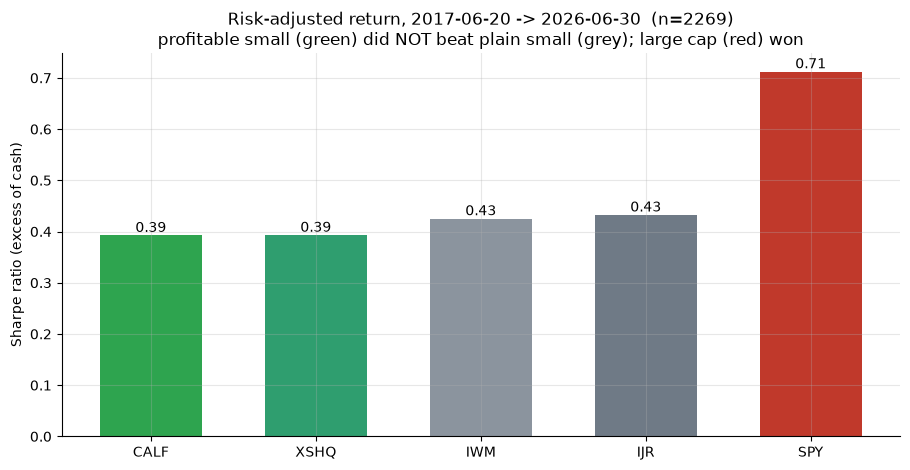

Sharpe: {'CALF': 0.393, 'XSHQ': 0.393, 'IWM': 0.425, 'IJR': 0.433, 'SPY': 0.712}


In [2]:
order = ['CALF','XSHQ','IWM','IJR','SPY']
if HAVE_REAL:
    r = st.race(FRAME, XLEGS)
    srs = [r['legs'][k]['sharpe'] for k in order]
    win = f"{r['start']} -> {r['end']}  (n={r['n']})"
else:
    srs = [R['race'][k]['sr'] for k in order]
    win = R['window'] + f"  (n={R['n_race']})"
cols = [GREEN, '#2f9e6f', GREY, '#6f7a86', RED]
fig, ax = plt.subplots(figsize=(9.2, 4.8))
bars = ax.bar(order, srs, color=cols, width=.62)
for k,v in zip(order, srs): ax.annotate(f'{v:.2f}', (k, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.6)
ax.set_ylabel('Sharpe ratio (excess of cash)')
ax.set_title('Risk-adjusted return, ' + win + '\nprofitable small (green) did NOT beat plain small (grey); large cap (red) won')
plt.tight_layout(); plt.show()
print('Sharpe:', {k: round(v,3) for k,v in zip(order, srs)})

The two green 'profitable small-cap' bars (0.39) sit **just below** the grey plain small-cap bars (0.42–0.43) — and everything small is dwarfed by the red S&P 500 bar (0.71). The quality screen bought no risk-adjusted advantage. If it did anything, it slightly *reduced* the Sharpe (CALF's big value-y bets also gave it the worst drawdown, -49%).

**But is that small gap even real, or just noise?** Let's put error bars on it.

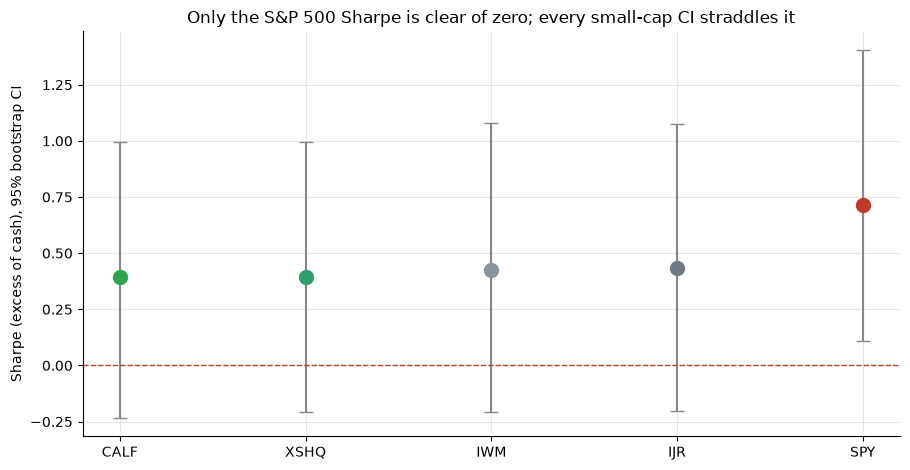

CALF: Sharpe +0.39  95% CI [-0.23, +1.00]
XSHQ: Sharpe +0.39  95% CI [-0.21, +0.99]
IWM: Sharpe +0.42  95% CI [-0.21, +1.08]
IJR: Sharpe +0.43  95% CI [-0.20, +1.07]
SPY: Sharpe +0.71  95% CI [+0.11, +1.41]


In [3]:
order = ['CALF','XSHQ','IWM','IJR','SPY']
if HAVE_REAL:
    win = st.common_window(FRAME, list(XLEGS.values()))
    pts, los, his = [], [], []
    for k in order:
        b = st.sharpe_ci_bootstrap(win[XLEGS[k]].to_numpy())
        pts.append(b['sharpe']); los.append(b['ci_low']); his.append(b['ci_high'])
else:
    pts = [R['boot'][k][0] for k in order]
    los = [R['boot'][k][1] for k in order]; his = [R['boot'][k][2] for k in order]
cols = [GREEN, '#2f9e6f', GREY, '#6f7a86', RED]
fig, ax = plt.subplots(figsize=(9.2, 4.8))
x = np.arange(len(order))
yerr = [np.array(pts)-np.array(los), np.array(his)-np.array(pts)]
ax.errorbar(x, pts, yerr=yerr, fmt='none', ecolor='#888', capsize=5)
for i,k in enumerate(order): ax.plot(x[i], pts[i], 'o', color=cols[i], ms=10)
ax.axhline(0, c=RED, lw=1, ls='--')
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel('Sharpe (excess of cash), 95% bootstrap CI')
ax.set_title('Only the S&P 500 Sharpe is clear of zero; every small-cap CI straddles it')
plt.tight_layout(); plt.show()
for k in order: print(f'{k}: Sharpe {R["boot"][k][0]:+.2f}  95% CI [{R["boot"][k][1]:+.2f}, {R["boot"][k][2]:+.2f}]')

Every small-cap fund's confidence interval **crosses zero** — on a resample there's a ~1-in-10 chance its excess-Sharpe was actually negative. Only **SPY** sits clearly in positive territory. So not only did profitable small caps fail to beat plain small caps — *no* small-cap Sharpe here is even reliably distinguishable from zero over these nine years.

**Was the quality screen doing anything at all, or just tracking plain small caps?**

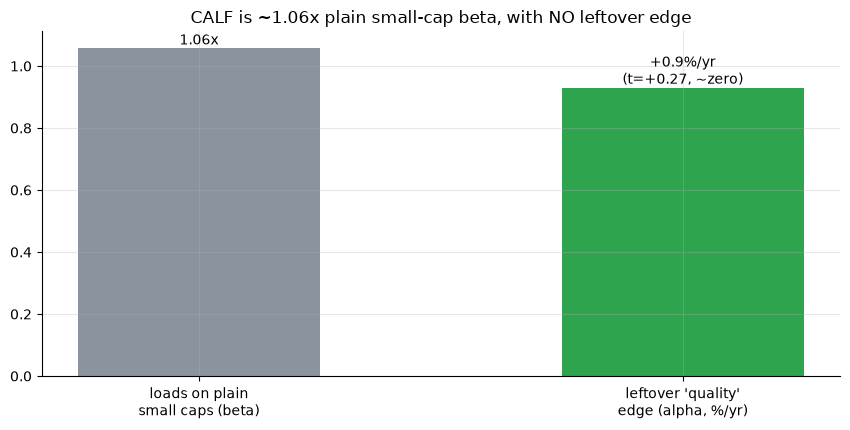

CALF beta on IWM = 1.06 ; leftover alpha = +0.93%/yr (t = +0.27)


In [4]:
if HAVE_REAL:
    d = st.beta_decomp(FRAME, 'x_CALF', ['x_IWM', 'x_SPY'])
    b_iwm, alpha, t_alpha = d['betas']['x_IWM'], d['alpha_ann_pct'], d['t_alpha']
else:
    dd = R['decomp']['CALF']; b_iwm, alpha, t_alpha = dd['b_iwm'], dd['alpha'], dd['t']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['loads on plain\nsmall caps (beta)', "leftover 'quality'\nedge (alpha, %/yr)"],
       [b_iwm, alpha], color=[GREY, GREEN], width=.5)
ax.annotate(f'{b_iwm:.2f}x', (0, b_iwm), ha='center', va='bottom')
ax.annotate(f'{alpha:+.1f}%/yr\n(t={t_alpha:+.2f}, ~zero)', (1, alpha), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.6); ax.set_title('CALF is ~1.06x plain small-cap beta, with NO leftover edge')
plt.tight_layout(); plt.show()
print(f'CALF beta on IWM = {b_iwm:.2f} ; leftover alpha = {alpha:+.2f}%/yr (t = {t_alpha:+.2f})')

> 🔬 **For the quants:** regress CALF's daily excess return on plain small caps (IWM) and the market (SPY). CALF loads **1.06×** on plain small caps, and the leftover alpha is **+0.9%/yr at *t* = 0.27** — indistinguishable from zero.

The 'profitable small-cap' fund is, statistically, just **plain small caps** with a fatter fee. There is no cleaned premium hiding in the risk-adjusted numbers.

## 5 · The verdict

- **Signal — None.** Profitable small caps (Sharpe 0.39) did **not** beat plain small caps (0.42); the gap is negative, noisy, and there's no risk-adjusted 'quality' alpha (~0.9%/yr, *t* ≈ 0.3). The machinery works — on a simulated world with a real planted edge it lights up cleanly (quants notebook) — so this is a true null, not a broken test.
- **Tradability — Mirage.** Nothing to bank; what looks like a candidate edge is pure small-cap beta, and CALF's 0.59% fee plus trading costs push the (already zero) gap negative.
- **'The size effect, cleaned' — Busted (as an ETF).** Over 2017–2026 the S&P 500 (Sharpe 0.71) beat every small-cap flavour. The quality screen didn't rescue the size premium into something you could buy.

## 6 · Going further 🚪

- **Long-short vs long-only.** AQR's result is a *long-short* one: long profitable small, **short junky small**. A long-only ETF can't short the junk, so it never isolates the clean premium — it just holds nicer small caps that still rise and fall with the whole small-cap tide.
- **The value tail wagged CALF.** CALF's cash-flow screen is really a *value* tilt; it had a huge 2021 and 2023 and an ugly 2024–2025. Big swings, no persistent risk-adjusted edge (see the calendar-year table in the quants notebook).
- **Cousins on the desk.** [513-size-effect](../../513-size-effect/README.md) tests the raw small-minus-big premium; [657-larry-portfolio](../../657-larry-portfolio/README.md) is the small-**value** tilt; [242-quality-minus-junk](../../242-quality-minus-junk/README.md) is the QMJ factor across all caps — this study is its small-cap-ETF slice; [362-piotroski-f-score](../../362-piotroski-f-score/README.md) is single-name quality scoring.

*Convinced 'quality small caps' must be better? Re-read the error-bar chart — then notice the boring red S&P 500 dot is the only one that clears zero.*